# Smart MCQ Solver Challenge

## Exploratory Data Analysis

This notebook performs exploratory data analysis on the Smart MCQ Solver dataset before preprocessing and model development.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load Dataset

In [42]:
train = pd.read_csv("/content/train.csv")
test = pd.read_csv("/content/test.csv")
sample_submission = pd.read_csv("/content/sample_submission.csv")

#Shape and Sample Check

In [45]:
print("="*50)
print("Dataset Shapes")
print("="*50)

print(f"Train Shape : {train.shape}")
print(f"Test Shape  : {test.shape}")
print(f"Submission  : {sample_submission.shape}")

Dataset Shapes
Train Shape : (2000, 8)
Test Shape  : (500, 7)
Submission  : (500, 2)


In [44]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


In [5]:
test.head()

,id,prompt,A,B,C,D,E
0,1,Pick the best possible answer: What is the rel...,"For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p...","For every eigenstate of one Hamiltonian, its p..."
1,2,"What is the estimated redshift of CEERS-93316,...","Approximately z = 6.0, corresponding to 1 bill...","Approximately z = 16.7, corresponding to 235.8...","Approximately z = 3.0, corresponding to 5 bill...","Approximately z = 10.0, corresponding to 13 bi...","Approximately z = 13.0, corresponding to 30 bi..."
2,3,Pick the best possible answer: What is the rea...,The sun appears yellowish due to a reflection ...,"The longer wavelengths of light, such as red a...",The sun appears yellowish due to the scatterin...,The sun emits a yellow light due to its own sp...,The atmosphere absorbs the shorter wavelengths...
3,4,What is the significance of the redshift-dista...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...,Observations of the redshift-distance relation...
4,5,What is the Landau-Lifshitz-Gilbert equation u...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...,The Landau-Lifshitz-Gilbert equation is a diff...


In [6]:
sample_submission.head()

,ID,Prediction
0,1,A B C
1,2,A B C
2,3,A B C
3,4,A B C
4,5,A B C


In [7]:
train.sample(5)

,id,prompt,A,B,C,D,E,answer
1606,1607,Choose the correct answer: What is Lorentz sym...,Lorentz symmetry or Lorentz invariance is a pr...,Lorentz symmetry or Lorentz invariance is a me...,Lorentz symmetry or Lorentz invariance is a ph...,Lorentz symmetry or Lorentz invariance is a me...,Lorentz symmetry or Lorentz invariance is an e...,E
484,485,Choose the correct answer: What are the four q...,"Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...","Holocrystalline, hypohyaline, hypercrystalline...","Holocrystalline, hypocrystalline, hypercrystal...","Holocrystalline, hypocrystalline, hypohyaline,...",B
1993,1994,Select the most accurate option: What is the J...,The Josephson effect is a phenomenon exploited...,The Josephson effect is a phenomenon exploited...,The Josephson effect is a phenomenon exploited...,The Josephson effect is a phenomenon exploited...,The Josephson effect is a phenomenon exploited...,A
310,311,Determine the correct option: What is the effe...,"An electric field, precisely aligned with the ...","A magnetic field, randomly aligned with the sp...","A magnetic field, precisely aligned with the s...","A gravitational field, randomly aligned with t...","A gravitational field, precisely aligned with ...",C
505,506,Select the most accurate option: What is the S...,"The SI base unit of time is the week, which is...","The SI base unit of time is the second, which ...","The SI base unit of time is the hour, which is...","The SI base unit of time is the day, which is ...","The SI base unit of time is the minute, which ...",B


In [8]:
test.sample(5)

,id,prompt,A,B,C,D,E
425,426,What is the significance of the speed of light...,The speed of light in vacuum is only relevant ...,The speed of light in vacuum is only relevant ...,The speed of light in vacuum is independent of...,The speed of light in vacuum is dependent on t...,The speed of light in vacuum is only relevant ...
412,413,Pick the best possible answer: What is the def...,The dimension of an object is the number of in...,The dimension of an object is the number of de...,The dimension of an object is the number of in...,The dimension of an object is the number of di...,The dimension of an object is the number of di...
395,396,Identify the correct statement: What is the or...,The permanent moment is generally due to the s...,The permanent moment is due to the alignment o...,The permanent moment is due to the torque prov...,The permanent moment is due to the quantum-mec...,The permanent moment is due to the interaction...
109,110,What is the main factor that determines the oc...,The star's distance from Earth,The star's age,The star's temperature,The star's luminosity,The progenitor star's metallicity
410,411,What is geometric quantization in mathematical...,Geometric quantization is a mathematical appro...,Geometric quantization is a mathematical appro...,Geometric quantization is a mathematical appro...,Geometric quantization is a mathematical appro...,Geometric quantization is a mathematical appro...


In [9]:
sample_submission.sample(5)

,ID,Prediction
391,392,A B C
109,110,A B C
81,82,A B C
185,186,A B C
79,80,A B C


In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      500 non-null    int64 
 1   prompt  500 non-null    object
 2   A       500 non-null    object
 3   B       500 non-null    object
 4   C       500 non-null    object
 5   D       500 non-null    object
 6   E       500 non-null    object
dtypes: int64(1), object(6)
memory usage: 27.5+ KB


#Missing Values and Duplicate Rows

In [46]:
print("Train Missing Values")

train.isnull().sum()

Train Missing Values


,0
id,0
prompt,0
A,0
B,0
C,0
D,0
E,0
answer,0


In [47]:
print("Test Missing Values")

test.isnull().sum()

Test Missing Values


,0
id,0
prompt,0
A,0
B,0
C,0
D,0
E,0


In [48]:
print(f"Duplicate Rows in Train : {train.duplicated().sum()}")

Duplicate Rows in Train : 0


#Distribution

In [49]:
train["answer"].value_counts()

,count
answer,
B,490
C,459
A,369
D,358
E,324


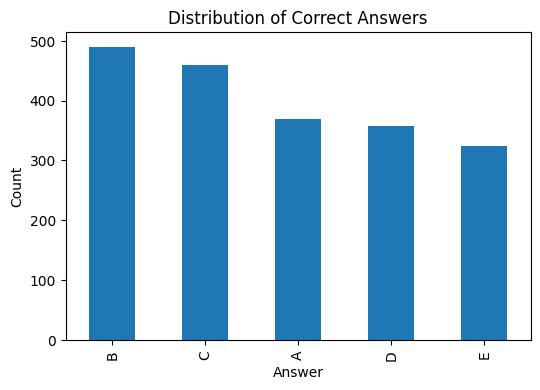

In [50]:
train["answer"].value_counts().plot(kind="bar",figsize=(6,4))

plt.title("Distribution of Correct Answers")
plt.xlabel("Answer")
plt.ylabel("Count")

plt.show()

#Prompt Length Analysis

In [51]:
prompt_length= train["prompt"].str.len()

In [52]:
prompt_length.describe()

,prompt
count,2000.000000
mean,117.669500
std,44.408674
min,19.000000
25%,87.750000
50%,111.000000
75%,141.000000
max,337.000000


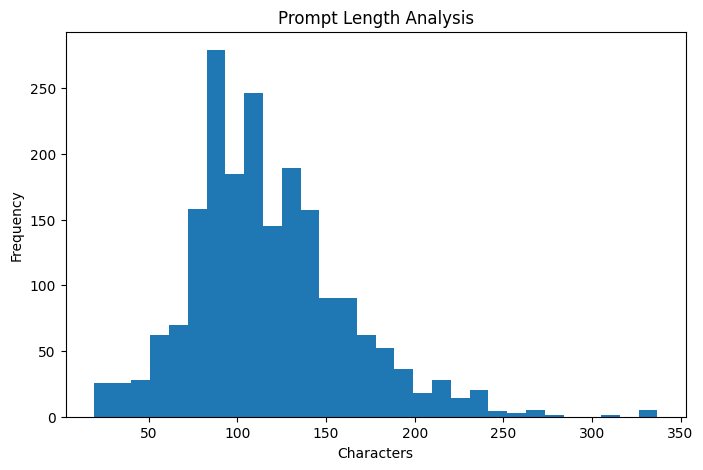

In [53]:
plt.figure(figsize=(8,5))
plt.hist(prompt_length, bins=30)

plt.title("Prompt Length Analysis")
plt.xlabel("Characters")
plt.ylabel("Frequency")

plt.show()

#Lets create a copy of training data for functional use

In [54]:
eda_train = train.copy()

#Option Lengths


In [55]:
options = ["A", "B", "C", "D", "E"]

for option in options:
  eda_train[f"{option}_length"] = eda_train[option].str.len()

In [56]:
eda_train[[f"{i}_length" for i in options]].describe()

,A_length,B_length,C_length,D_length,E_length
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,164.091500,166.616500,167.227000,162.56350,164.230000
std,105.677145,113.829917,105.723674,104.11657,107.777712
min,1.000000,2.000000,2.000000,1.00000,2.000000
25%,86.000000,82.000000,88.000000,91.00000,84.000000
50%,143.000000,151.000000,158.000000,141.00000,144.000000
75%,234.000000,222.000000,224.000000,231.00000,224.000000
max,472.000000,662.000000,530.000000,450.00000,587.000000


#Class Balance

In [57]:
answer_percentage = (train["answer"].value_counts(normalize=True).mul(100).round(2))
display(answer_percentage)

,proportion
answer,
B,24.50
C,22.95
A,18.45
D,17.90
E,16.20


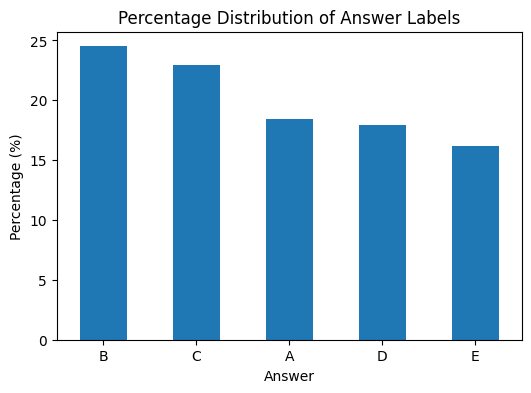

In [58]:
plt.figure(figsize=(6,4))
answer_percentage.plot(kind="bar")

plt.title("Percentage Distribution of Answer Labels")
plt.xlabel("Answer")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.show()

#Prompt Length by Answer Class

In [59]:
prompt_analysis = pd.DataFrame({
    "answer": train["answer"],
    "prompt_length": prompt_length
})

prompt_analysis.groupby("answer")["prompt_length"].mean()

,prompt_length
answer,
A,124.888889
B,124.212245
C,111.039216
D,118.033520
E,108.543210


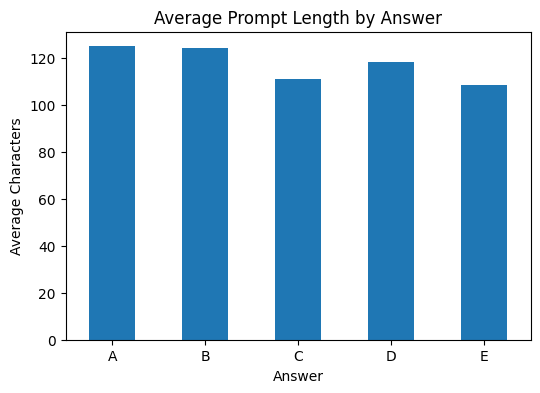

In [60]:
prompt_analysis.groupby("answer")["prompt_length"].mean().plot(kind="bar", figsize=(6,4))

plt.title("Average Prompt Length by Answer")
plt.xlabel("Answer")
plt.ylabel("Average Characters")

plt.xticks(rotation=0)

plt.show()

#Unique Values

In [ ]:
unique_values = pd.DataFrame({
    "Column": train.columns,
    "Unique Values": [train[col].nunique() for col in train.columns]
})

unique_values

#Memory Usage

In [62]:
memory_usage = train.memory_usage(deep=True).sum() / (1024**2)

print(f"Memory Usage: {memory_usage:.2f} MB")

Memory Usage: 2.79 MB


# Observations

- The training dataset contains 2,000 samples with 8 Columns and the test dataset contains 500 samples.
- No missing values were found.
- No Duplicate records were detected.
- The answer labels are approximately balanced across all five classes.
- Prompt lengths vary across questions.
- Option lengths are relatively short compared to prompts.
- The dataset occupies only a small amount of memory, making it suitable for experimentation.
